In [1]:
import OpenGL.GL.ARB.imaging
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

#load the necessary odometry modules
from cpsl_datasets.cpsl_ds import CpslDS
from cpsl_datasets.map_handler import MapHandler
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator
from odometry.test_benches.point_cloud_integrator_tb import PointCloudIntegratorTB
from odometry.test_benches._test_bench import _TestBench, PredictionSource, GroundTruthSource, OdomCoordinateFrame
from odometry.point_cloud_processing.accumulation.integrators._pc_integrator import _PointCloudIntegrator
from odometry.point_cloud_processing.accumulation.integrators._pc_integrator_gnn_runner import _PointCloudIntegratorGnnRunner
from mmwave_model_integrator.model_runner.gnn_runner import GNNRunner
from mmwave_model_integrator.torch_training.models.TwoStreamSpatioTemporalGnn import TwoStreamSpatioTemporalGnn

from odometry.test_benches.point_cloud_integrator_unet_tb import PointCloudIntegratorTB
from odometry.point_cloud_processing.clustering.occlusion_aware_clustering import OcclusionAwareClustering
from odometry.point_cloud_processing.clustering.two_stage_occlusion_aware_clustering import TwoStageOcclusionAwareClustering

from mmwave_model_integrator.dataset_generators._online_dataset_generator import _OnlineDatasetGenerator
from mmwave_model_integrator.input_encoders._node_encoder import _NodeEncoder
from mmwave_model_integrator.ground_truth_encoders._gt_node_encoder import _GTNodeEncoder

In [2]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
# DATASET_PATH=os.getenv("DATASET_DIRECTORY")
# MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")
# GENERATED_DATASETS_PATH=os.getenv("GENERATED_DATASETS_PATH")

DATASET_PATH = "/data/IcaRAus/datasets/UGV"
MAP_DIRECTORY = "/data/IcaRAus/maps"
GENERATED_DATASETS_PATH = "/data/IcaRAus/generated_datasets"
generate_movie = False

# #setup the datasets
folder_name = "WILK" #"WILK", "NORTH_VICON", "NORTH_1ST", "CPSL"
file_name = "IcaRAus_ugv_wilk_2_5m" # "IcaRAus_ugv_wilk_2_5m", "north_vicon_1", "north_1st_1", "IcaRAus_ugv_cpsl_1_5m"
# file_name = "WILK_Multipath_Test_5" #for point cloud comparison (frame 1340)
# file_name = "WILK_Path_1_Same_Side_Dynamic_1"
# file_name = "wilk_basement_3" #wilk_basement_2 for point cloud processing (frame 780)

normalize_frames = True
num_frames_history = 50
config_label = "IcaRAus_gnn_{}fh_grids".format(num_frames_history)
results_parent_folder = "{}_train".format(config_label)
print(os.path.join(DATASET_PATH,folder_name,file_name))
dataset = CpslDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name),
    radar_pc_folder="radar_combined_pc",
    lidar_folder="lidar",
    camera_folder="camera",
    vehicle_odom_folder="vehicle_odom",
    vicon_folder="vicon_x500_8"
)
print(dataset.num_frames)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilk_map.yaml"#"cpsl_map.yaml", "wilk_map", "north_vicon_1", "north_1st_map"
)

/data/IcaRAus/datasets/UGV/WILK/IcaRAus_ugv_wilk_2_5m
found 4857 radar point cloud samples
found 4857 lidar samples
found 4857 camera samples
found 4856 vehicle odometry samples
did not find vicon samples
4856
loaded map from /data/IcaRAus/maps/wilk_map.yaml
loaded map free space from /data/IcaRAus/maps/wilk_map.yaml


In [3]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.25,#0.1
    icp_best_points_percentile=60, #80
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #7
    icp_max_iterations=5, #20
    self_detection_radius_m=0 #originally 1.5
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.1, #was 0.6, try 0.1
    icp_best_points_percentile=50, #was 50 - try 75
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=1.0 #was 0.25, try 1.0
)

In [4]:
#initialize the dataset encoders
input_encoder = _NodeEncoder()
gt_encoder = _GTNodeEncoder()

#initialize the dataset generator
generated_dataset_path = os.path.join(GENERATED_DATASETS_PATH,"{}_train".format(config_label))
dataset_generator = _OnlineDatasetGenerator(
    generated_dataset_path=generated_dataset_path,
    input_encoder=input_encoder,
    ground_truth_encoder=gt_encoder,
    generated_file_name="frame",
    input_encoding_folder="nodes",
    ground_truth_encoding_folder="labels",
    clear_existing_data=True
)

DatasetGenerator._check_for_directory: found directory /data/IcaRAus/generated_datasets/IcaRAus_gnn_50fh_grids_train
DatasetGenerator._check_for_directory: clearing contents of /data/IcaRAus/generated_datasets/IcaRAus_gnn_50fh_grids_train
DatasetGenerator._check_for_directory: found directory /data/IcaRAus/generated_datasets/IcaRAus_gnn_50fh_grids_train/nodes
DatasetGenerator._check_for_directory: clearing contents of /data/IcaRAus/generated_datasets/IcaRAus_gnn_50fh_grids_train/nodes
DatasetGenerator._check_for_directory: found directory /data/IcaRAus/generated_datasets/IcaRAus_gnn_50fh_grids_train/labels
DatasetGenerator._check_for_directory: clearing contents of /data/IcaRAus/generated_datasets/IcaRAus_gnn_50fh_grids_train/labels


In [5]:
#initialize the probabilistic point cloud grid
# point_cloud_integrator = _PointCloudIntegrator(
#     gt_distance_threshold_m=0.5,
#     num_frames_history=num_frames_history,
#     min_detection_radius=1.0,
#     max_detection_radius=5.0
# )

#if testing the gnn runner
model = TwoStreamSpatioTemporalGnn(
    hidden_channels=28,
    out_channels=1,
    k=4, #original is 40
    dropout=0.1
)

runner = GNNRunner(
    model= model,
    state_dict_path = "/home/david/Downloads/IcaRAus_TwoStreamSpatioTemporalGnn_IcaRAus_ds_50fh_k4.pth",
    cuda_device="cpu",
    edge_radius=10.0, #unused for this model
    enable_downsampling=True,
    downsample_keep_ratio=0.50,
    downsample_min_points=300,
    use_sigmoid=True
)

point_cloud_integrator = _PointCloudIntegratorGnnRunner(
    gnn_runner=runner,
    num_frames_history=num_frames_history,
    num_frames_history_gt=1,
    min_detection_radius=0.25,
    max_detection_radius=8.0,
    normalize_frames=True,
    gt_distance_threshold_m=0.25,
    grid_resolution_m=0.1,
    gt_occlusion_aware_clustering=OcclusionAwareClustering(
        clustering_eps=0.2,
        clustering_min_samples=12,
        angle_res_rad=0.017,
        occlusion_threshold=0.7,
        subsample_percentage=1.0
    )
)

#if testing dataset generation
# point_cloud_integrator = _PointCloudIntegrator(
#     gt_distance_threshold_m=0.25,
#     num_frames_history=num_frames_history,
#     min_detection_radius=1.0,
#     max_detection_radius=5.0, #originally 5.0
# )

#dynamic point cloud integrator
dynamic_point_cloud_integrator = _PointCloudIntegrator(
    gt_distance_threshold_m=0.5,
    num_frames_history=num_frames_history,
    min_detection_radius=1.0,
    max_detection_radius=4.0
)

_ModelRunner: using CPU
Total number of parameters: 19729


loaded map with 12752 points
gt icp estimated heading:-5.683332074949396 deg, pose:[-0.20827405 -0.02532009]
loaded map with 12752 points


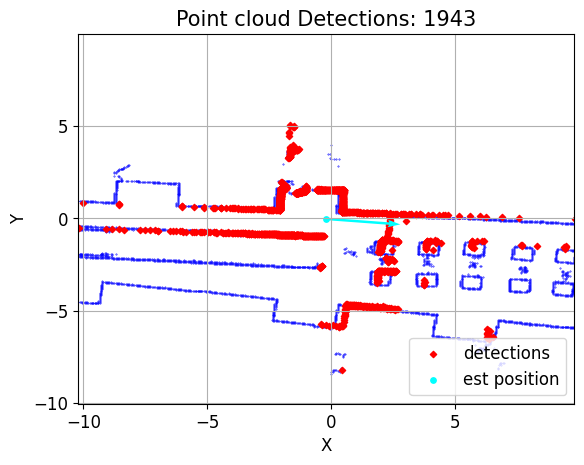

In [6]:
test_bench = PointCloudIntegratorTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    point_cloud_integrator=point_cloud_integrator,
    dynamic_point_cloud_integrator=dynamic_point_cloud_integrator,
    model_dataset_generator=dataset_generator,
    use_filters=True,
    prediction_source=PredictionSource.VEHICLE_ODOM,
    gt_source=GroundTruthSource.LIDAR,
    odom_frame=OdomCoordinateFrame.FLU
)

if file_name== "north_1st_4":
    start_heading = np.deg2rad(45)
    start_pose = np.array([1.0,0.5])
else:
    start_heading = np.deg2rad(0)
    start_pose = np.array([0.00,0.00])

#initialize the localization
new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

#initialize the filter
test_bench.init_filter(
    est_start_heading_rad=new_heading_rad,
    est_start_position_m=new_pose_m,
    start_time_s=test_bench.get_dataset_start_time(idx=0),
    gyro_bias=-0.0024 #originally -0.0024
)

In [7]:
end_idx = 100 #for full dataset, use "dataset.num_frames" #point cloud sample: frame 1340 on Wilk_Multipath_test_5 (960 for pc compare, 980 for block diagram)
save_name = config_label + "radar_combined"
test_bench.run(
    max_frame=end_idx,
    gt_enabled=True, #if not desired set to False
    movie_generator=None,
    generate_dataset=False) #use generator script in scripts folder instead

#run to around 1:07 mark for looking at the point cloud

100%|██████████| 100/100 [00:03<00:00, 28.18it/s]


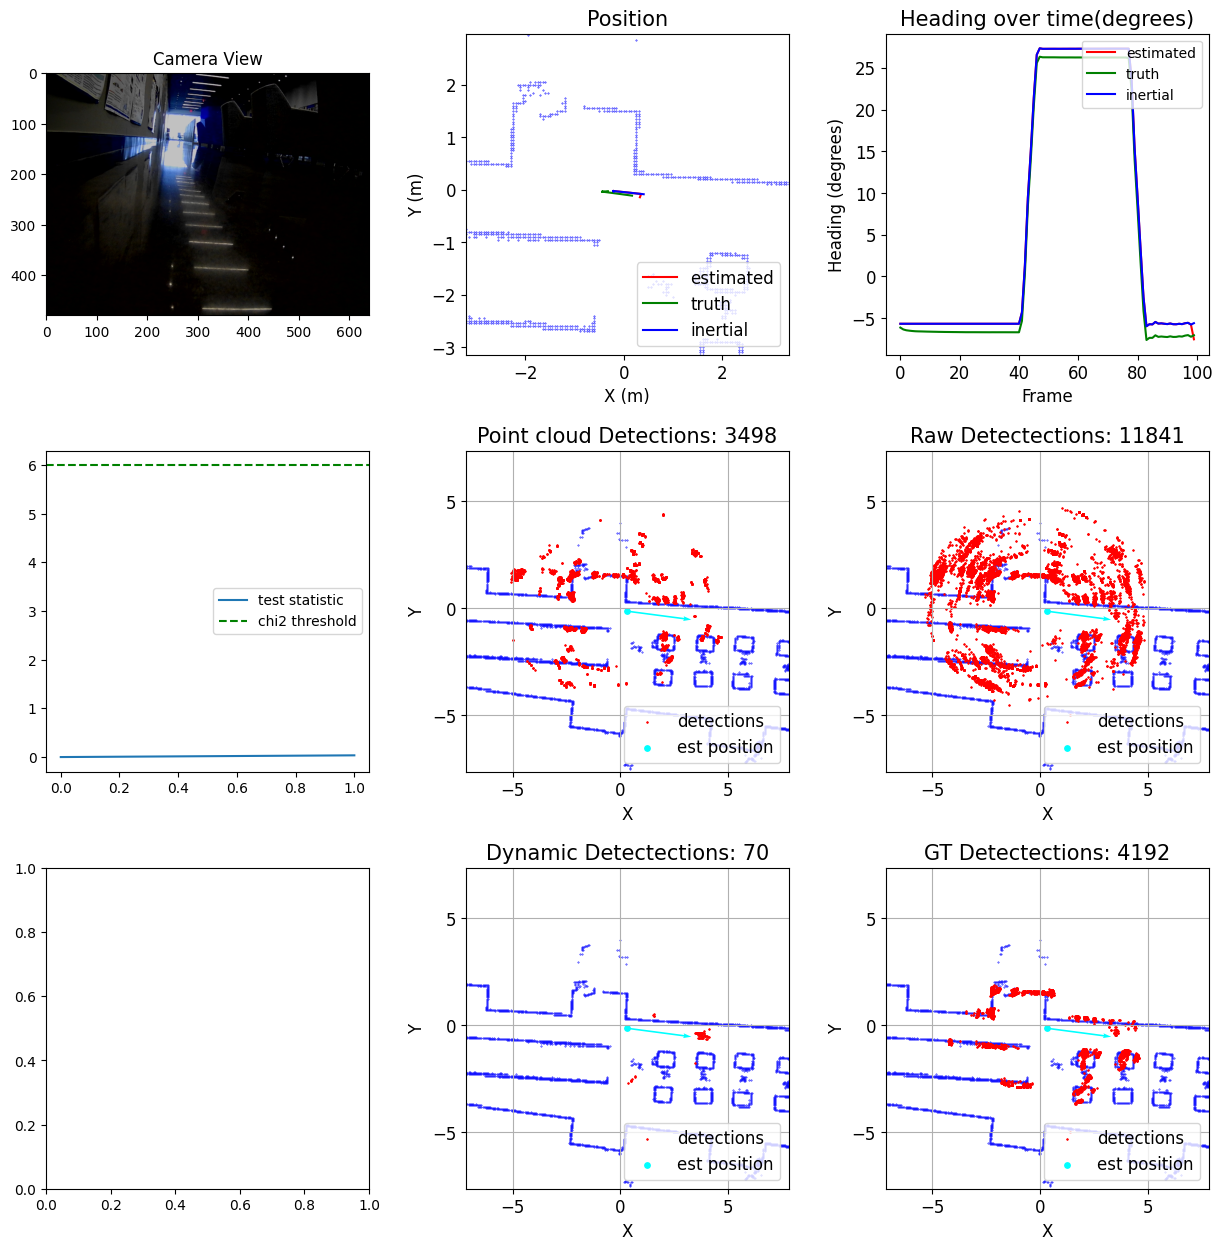

In [8]:
axs = test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

In [33]:
#get GT point cloud at current index
from odometry.point_cloud_processing.pc_range_filter import pcRangeFilter



def get_gt_pc(idx:int)-> np.ndarray:

    pc_range_filter = pcRangeFilter(
        min_detection_radius_m=0.5,
        max_detection_radius_m=test_bench.point_cloud_integrator.max_detection_radius
    )

    gt_points = test_bench.dataset.get_lidar_point_cloud_raw(idx)

    gt_points = pc_range_filter.get_points_in_detection_range(
        points=gt_points
    )
    
    #filter out ground, set z coordinate to 0 for remaining points
    valid_points = gt_points[:,2] > -0.1 #filter out ground
    valid_points = valid_points & (gt_points[:,2] < 0.5) #higher elevation points
    gt_points = gt_points[valid_points,:3]
    gt_points[:,2] = 0.0

    return gt_points

    


[ 0.16749298 -0.11230471]
-7.059685348880265


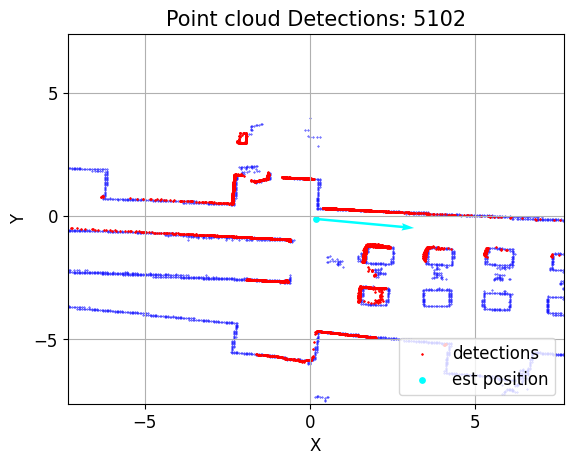

In [34]:
#get the lidar ground truth point cloud
current_pose = test_bench.history_position_m_gt[end_idx-1]
print(current_pose)
current_heading = test_bench.history_heading_deg_gt[end_idx-1]
print(current_heading)

gt_points = get_gt_pc(idx=end_idx)

test_bench.plotter_localization.plot_detections_on_map(
    current_points=gt_points[:,0:2],
    heading_rad=np.deg2rad(current_heading),
    pose_m=current_pose,
    show=True
)

(2482, 3)


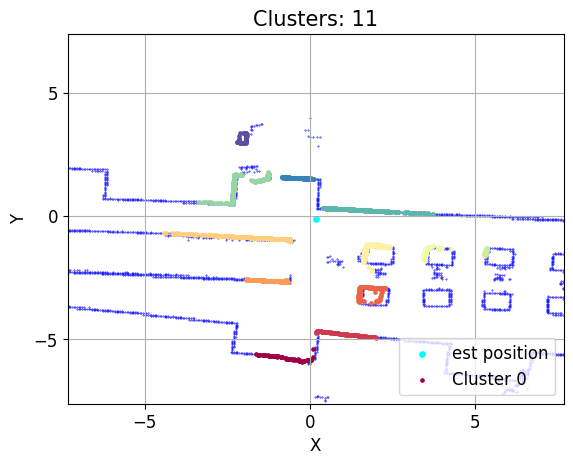

In [35]:
from odometry.point_cloud_processing.clustering.occlusion_aware_clustering import OcclusionAwareClustering
detector = OcclusionAwareClustering(
    clustering_eps=0.2,
    clustering_min_samples=12,
    angle_res_rad=0.017,
    occlusion_threshold=0.4,
    subsample_percentage=0.5)

# Run the pipeline
gt_points_valid, labels, vis_ids = detector.process(gt_points)
print(gt_points_valid.shape)

# Pass results to your plotting function
test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=gt_points_valid[:,0:2],
    labels=labels,
    heading_rad=np.deg2rad(current_heading),
    pose_m=current_pose,
    show=True
)

(11841, 4)


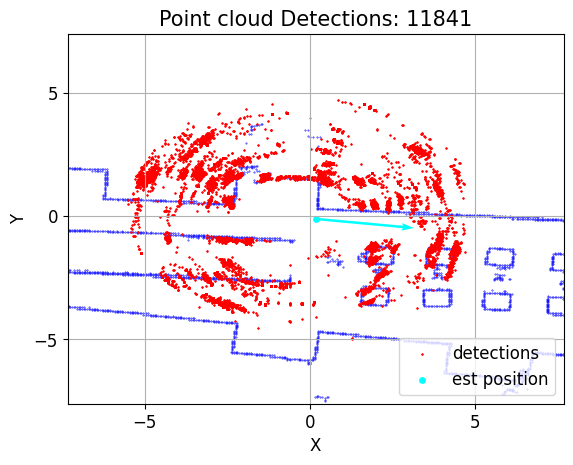

In [36]:
radar_dets = test_bench.point_cloud_integrator.get_raw_point_history()
print(radar_dets.shape)
test_bench.plotter_localization.plot_detections_on_map(
    current_points=radar_dets[:,0:2],
    heading_rad=np.deg2rad(current_heading),
    pose_m=current_pose,
    show=True
)

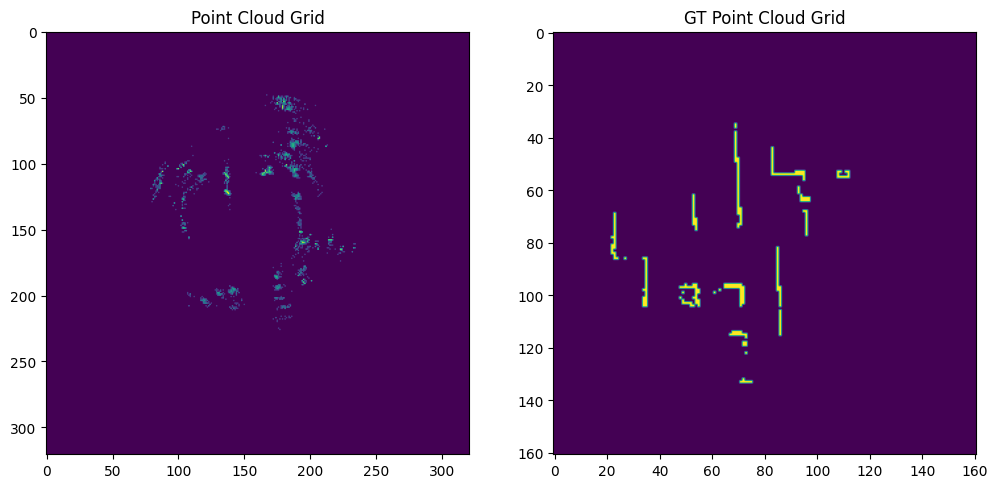

In [37]:
from odometry.point_cloud_processing.accumulation.pc_accumulator import PcAccumulator

pc_accumulator = PcAccumulator(
    max_detection_range=8.0,
    grid_resolution_m=0.05
)
# Convert the point cloud to a grid

detector = OcclusionAwareClustering(
    clustering_eps=0.2,
    clustering_min_samples=10,
    angle_res_rad=0.017,
    occlusion_threshold=0.4,
    subsample_percentage=0.5)

# Run the pipeline
filtered_radar_dets, labels, vis_ids = detector.process(radar_dets)

pc_grid = pc_accumulator._get_density_grid_from_points(
    points=filtered_radar_dets
)

gt_pc_grid = test_bench.point_cloud_integrator.raw_point_history._get_grid_from_points(
    points=gt_points_valid
)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the Point Cloud Grid on the left (index 0)
axes[0].imshow(pc_grid)
axes[0].set_title("Point Cloud Grid")

# Plot the Ground Truth (GT) PC Grid on the right (index 1)
axes[1].imshow(gt_pc_grid)
axes[1].set_title("GT Point Cloud Grid")

# Display the plots
plt.show()

(5319, 3)


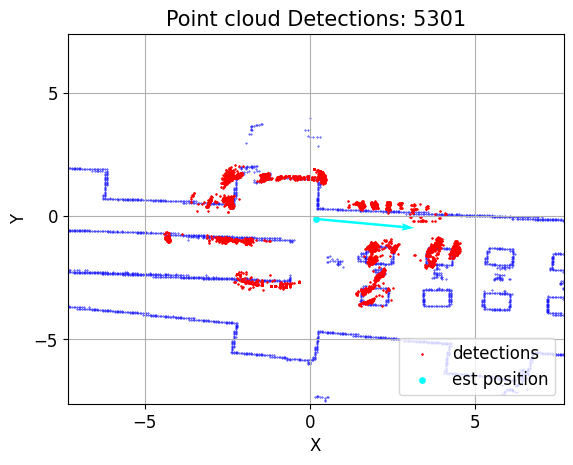

In [38]:
#get the radar detections that are close to the gt points

valid_radar_pts = test_bench.point_cloud_integrator.raw_point_history._get_dets_close_to_gt_points(
    dets=radar_dets[:,0:3],
    gt_points=gt_points_valid[:,0:3],
    threshold=0.4
)

#apply a round of clustering to remove miscellaneous points
detector = OcclusionAwareClustering(
    clustering_eps=0.2,
    clustering_min_samples=12,
    subsample_percentage=1.0)
visible_pc_radar, labels_radar, vis_ids_radar = detector.process(valid_radar_pts)

print(valid_radar_pts.shape)

# Pass results to your plotting function
test_bench.plotter_localization.plot_detections_on_map(
    current_points=visible_pc_radar[:,0:2],
    heading_rad=np.deg2rad(current_heading),
    pose_m=current_pose,
    show=True
)

Original radar_dets shape: (11841, 4)
Current pose: [ 0.16749298 -0.11230471]
Current heading: -7.059685348880265


100%|██████████| 100/100 [00:01<00:00, 55.89it/s]


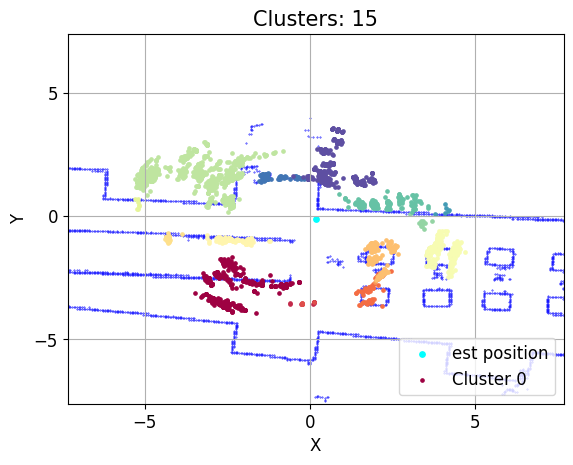

In [39]:
import numpy as np
from odometry.point_cloud_processing.clustering.two_stage_occlusion_aware_clustering import TwoStageOcclusionAwareClustering

# Get original data
radar_dets, labels_original = test_bench.point_cloud_integrator.get_nodes(normalize_frames=True) 
print(f"Original radar_dets shape: {radar_dets.shape}")

# Get current position and heading
current_pose = test_bench.history_position_m_gt[end_idx-1]
print(f"Current pose: {current_pose}")
current_heading = test_bench.history_heading_deg_gt[end_idx-1]
print(f"Current heading: {current_heading}")

# --- Apply KNN Filtering ---
clustering = OcclusionAwareClustering(
    clustering_eps=0.2,
    clustering_min_samples=5,
    angle_res_rad=0.017,
    occlusion_threshold=0.9,
    subsample_percentage=0.40
)
# clustering = TwoStageOcclusionAwareClustering(
#     knn_neightbors=5, #10
#     knn_distance_threshold=0.2, #0.1
#     clustering_eps=0.20, #0.15
#     clustering_min_samples=5, #10
#     angle_res_rad=0.017,
#     occlusion_threshold=0.9,
#     subsample_percentage=0.5
# )

# Fit NearestNeighbors on the x,y coordinates
for i in tqdm(range(100)):
    
    filtered_radar_dets, cluster_labels, vis_ids_radar = clustering.process(radar_dets[:,0:4])


test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=filtered_radar_dets[:,0:2],
    labels=cluster_labels,
    heading_rad=np.deg2rad(current_heading),
    pose_m=current_pose,
    show=True
)

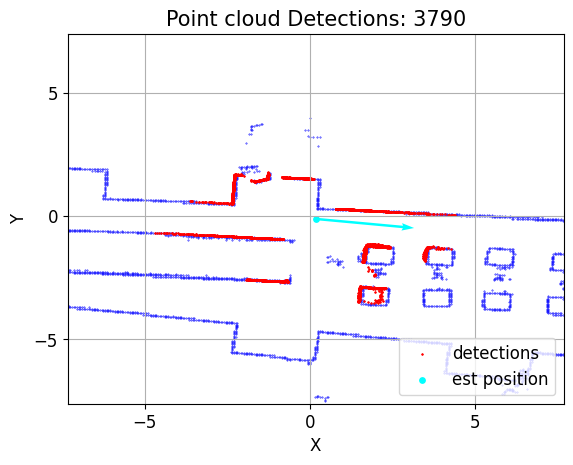

In [40]:
#plot the "GT points based on proximity to radar points"
gt_points = get_gt_pc(idx=end_idx)

gt_points, _, _ =\
    test_bench.point_cloud_integrator.raw_point_history.gt_occlusion_aware_clustering.process(gt_points)


gt_points_valid = test_bench.point_cloud_integrator.raw_point_history._get_gt_points_close_to_dets(
    dets=filtered_radar_dets[:,0:3],
    gt_points=gt_points,
    threshold=0.4
)

test_bench.plotter_localization.plot_detections_on_map(
    current_points=gt_points_valid[:,0:2],
    heading_rad=np.deg2rad(current_heading),
    pose_m=current_pose,
    show=True
)

(253, 3)


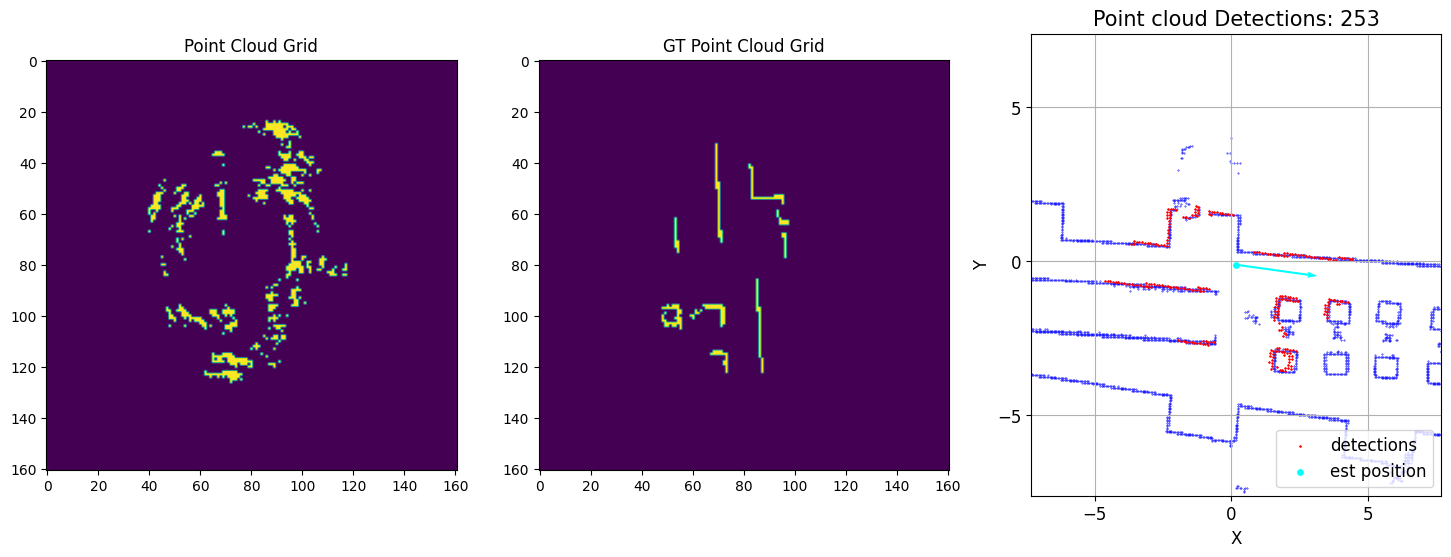

In [42]:
# Convert the point cloud to a grid
pc_grid = test_bench.point_cloud_integrator.raw_point_history._get_grid_from_points(
    points=filtered_radar_dets
)

gt_pc_grid = test_bench.point_cloud_integrator.raw_point_history._get_grid_from_points(
    points=gt_points_valid
)

gt_pc_reproduced = test_bench.point_cloud_integrator.raw_point_history._get_points_from_pc_grid(
    pc_grid=gt_pc_grid
)
print(gt_pc_reproduced.shape)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot the Point Cloud Grid on the left (index 0)
axes[0].imshow(pc_grid)
axes[0].set_title("Point Cloud Grid")

# Plot the Ground Truth (GT) PC Grid on the right (index 1)
axes[1].imshow(gt_pc_grid)
axes[1].set_title("GT Point Cloud Grid")

#plot the reproduced grid
test_bench.plotter_localization.plot_detections_on_map(
    current_points=gt_pc_reproduced[:,0:2],
    heading_rad=np.deg2rad(current_heading),
    pose_m=current_pose,
    ax=axes[2],
    show=False
)

# Display the plots
plt.show()